In [1]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3.5-9B"

In [2]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    low_cpu_mem_usage=True,
    device_map="cpu",
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

In [3]:
text = "This is a sentence about thermodynamics."

encoded_text = tokenizer.encode(text)

print(encoded_text)

decoded_text = [tokenizer.decode(encoded_text[i]) for i in range(len(encoded_text))]

print(decoded_text)

[1919, 369, 264, 11316, 883, 28868, 76214, 13]
['This', ' is', ' a', ' sentence', ' about', ' therm', 'odynamics', '.']


In [4]:
# Get the row norms
if hasattr(model, "lm_head") and model.lm_head is not None:
    tensor = model.lm_head.weight.detach()
    tensor_name = "lm_head.weight"
else:
    # Tied embeddings fallback (shouldn't trigger for Qwen3.5-9B,
    # which has tie_word_embeddings=False).
    tensor = model.get_input_embeddings().weight.detach()
    tensor_name = "model.embed_tokens.weight (tied)"

print(f"Tensor '{tensor_name}' shape: {tuple(tensor.shape)}")
# Shape is (vocab_size, d_model) = (V, d_model), so rows (dim=1
# reduction) are the per-token unembedding vectors.
norms = torch.linalg.norm(tensor.float(), dim=1).numpy()

Tensor 'lm_head.weight' shape: (248320, 4096)


Standard Deviation: 0.11848074197769165


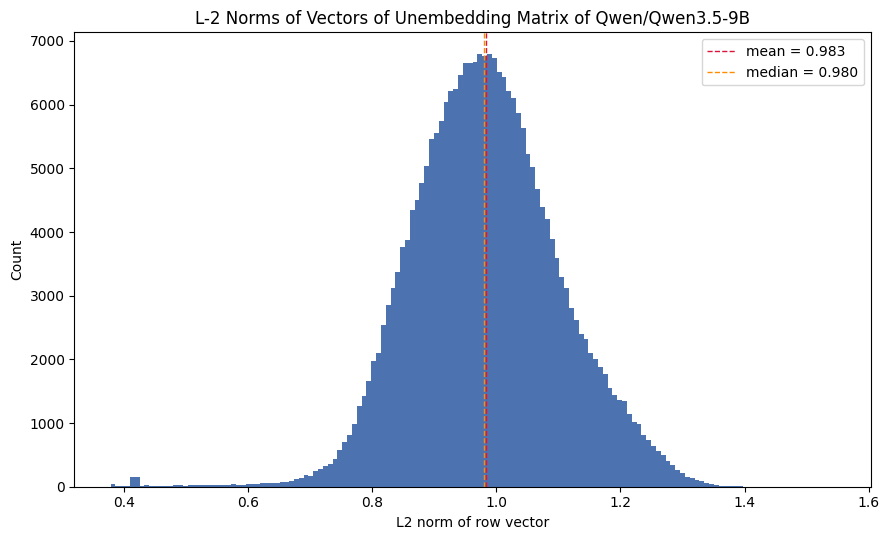

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(norms, bins=150, color="#4C72B0", edgecolor="none")
ax.set_xlabel("L2 norm of row vector")
ax.set_ylabel("Count")
ax.set_title(f"L-2 Norms of Vectors of Unembedding Matrix of {MODEL_NAME}")
ax.axvline(np.mean(norms), color="crimson", linestyle="--", linewidth=1,
            label=f"mean = {np.mean(norms):.3f}")
ax.axvline(np.median(norms), color="darkorange", linestyle="--",
            linewidth=1, label=f"median = {np.median(norms):.3f}")
ax.legend()
fig.tight_layout()

print(f"Standard Deviation: {np.std(norms)}")

In [6]:
# Look at tokens with high and low norms
k = 15

def token_repr(idx):
    try:
        tok = tokenizer.convert_ids_to_tokens(int(idx))
    except Exception:
        tok = None
    if tok is None:
        tok = tokenizer.decode([int(idx)])
    return tok

order = np.argsort(norms)
lowest_idx = order[:k]
highest_idx = order[::-1][:k]

print(f"\nTop {k} HIGHEST-norm tokens:")
for idx in highest_idx:
    print(f"  id={idx:<8d} norm={norms[idx]:.4f}  token={token_repr(idx)!r}")

print(f"\nTop {k} LOWEST-norm tokens:")
for idx in lowest_idx:
    print(f"  id={idx:<8d} norm={norms[idx]:.4f}  token={token_repr(idx)!r}")


Top 15 HIGHEST-norm tokens:
  id=248050   norm=1.5449  token='<|box_end|>'
  id=86323    norm=1.4338  token='strup'
  id=232078   norm=1.4315  token='hofer'
  id=69906    norm=1.4271  token='ĠâĢĭâĢĭ'
  id=37032    norm=1.4189  token='edList'
  id=59559    norm=1.4188  token='baugh'
  id=202992   norm=1.4145  token='egger'
  id=234646   norm=1.4118  token='enius'
  id=107357   norm=1.4064  token='éĩĳæ£®'
  id=32952    norm=1.4045  token='heimer'
  id=75782    norm=1.4016  token='uzzi'
  id=123159   norm=1.3995  token='æĶ¶èĹıæľ¬ç«Ļ'
  id=39762    norm=1.3934  token='oyer'
  id=193446   norm=1.3930  token='ymar'
  id=109736   norm=1.3915  token='å¾®ä¿¡æī«ä¸Ģæī«'

Top 15 LOWEST-norm tokens:
  id=85329    norm=0.3787  token='useRalative'
  id=229465   norm=0.3792  token='Ġtarsker'
  id=157743   norm=0.3793  token='ë¦½ìĸ´ëĵľë°ĶìĿ´ìłĢ'
  id=179115   norm=0.3793  token='ÑģÐ¼Ð°ÑĤÑĢÐ¸'
  id=138563   norm=0.3794  token='æī¿æĭħä¸ĢåĪĩåĽłæĤ¨çļĦè¡Įä¸ºèĢĮçĽ´æİ¥æĪĸéĹ´æİ¥'
  id=107656   norm=0.3794  to

In [7]:
# Look at norms of a few tokens
tokens = ["the", "The", "and", ".", "1", "2", "3", "blackmail", "artifice", "plagiarism", "of", "Qwen", "AI", "LLM", "antidistablishmentarianism", "cheating", "forgery"]

for token in tokens:
    id = tokenizer.encode(token)
    print(f"{norms[id]}: {token}")


[0.8325997]: the
[0.74443877]: The
[1.0042259]: and
[0.9879579]: .
[1.1080428]: 1
[1.0828502]: 2
[1.0218183]: 3
[0.85498196 1.0710937 ]: blackmail
[1.1238627 1.152443 ]: artifice
[1.057591  1.1054049 1.2327728 1.1265664]: plagiarism
[1.027353]: of
[1.0242798 1.1580391]: Qwen
[0.98395896]: AI
[1.017073  1.0259587]: LLM
[1.1462262 1.1058313 1.1235284 1.2749562 1.2336355 1.2195795 1.1265664]: antidistablishmentarianism
[1.1670215 1.0513862]: cheating
[1.104685  1.1881955]: forgery
